In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from imblearn.over_sampling import SMOTE

In [2]:
# Load Kaggle dataset (creditcard.csv)
df = pd.read_csv("creditcard.csv")

# Basic exploration
print(df.shape)
print(df.head())
print(df['Class'].value_counts())

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

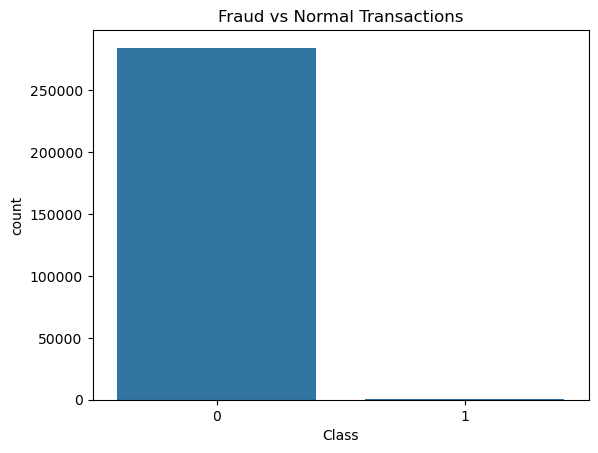

In [3]:
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

In [4]:
X = df.drop('Class', axis=1)
y = df['Class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Handle imbalance with SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# 1. Define models with reduced complexity
models = {
    "lr": LogisticRegression(max_iter=200), # Lowered max_iter
    "rf": RandomForestClassifier(n_estimators=50, n_jobs=-1), # Fewer trees, use all CPU cores
    "xgb": xgb.XGBClassifier(n_estimators=50, tree_method='hist', n_jobs=-1) # Histogram method is much faster
}

results = {}

# 2. Train and Predict in a single loop
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    results[f"pred_{name}"] = model.predict(X_test)
    results[f"prob_{name}"] = model.predict_proba(X_test)[:, 1]

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



LR Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.07      0.91      0.13        98

    accuracy                           0.98     56962
   macro avg       0.54      0.94      0.56     56962
weighted avg       1.00      0.98      0.99     56962


RF Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.85      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962


XGB Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.65      0.84      0.73        98

    accuracy                           1.00     56962
   macro avg       0.83      0.92      0.87   

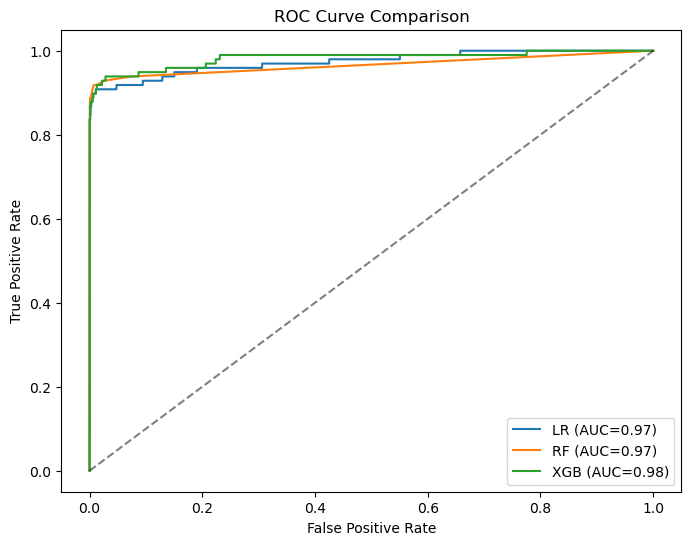

In [8]:
from sklearn.metrics import classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Loop through the results we stored in the previous step
for name in ["lr", "rf", "xgb"]:
    # 1. Print Reports
    print(f"\n{name.upper()} Classification Report:")
    print(classification_report(y_test, results[f"pred_{name}"]))
    
    # 2. Plot ROC Curves
    fpr, tpr, _ = roc_curve(y_test, results[f"prob_{name}"])
    auc = roc_auc_score(y_test, results[f"prob_{name}"])
    plt.plot(fpr, tpr, label=f"{name.upper()} (AUC={auc:.2f})")

# Final Plot Styling
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5) # alpha reduces ink load/visual clutter
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.show()

Total Transactions: 56962
Fraudulent Transactions: 98 (0.17%)


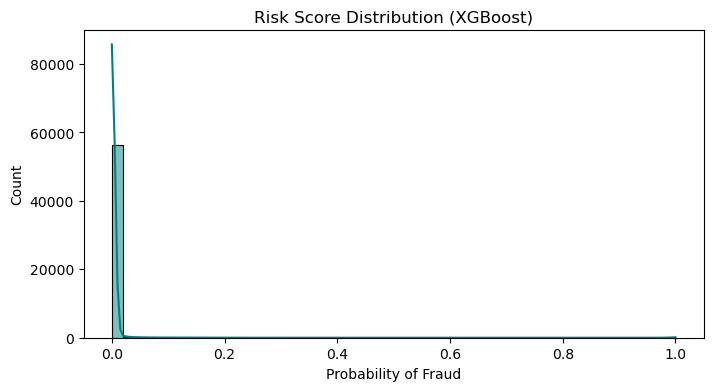


Top 10 High-Risk Transactions:
        RiskScore
229712   0.999990
541      0.999990
243699   0.999987
6717     0.999985
15476    0.999985
15225    0.999985
15539    0.999985
42769    0.999983
150663   0.999982
42756    0.999980


In [10]:
# 1. Attach results to a lightweight view
df_test = X_test.copy()
df_test['Actual'] = y_test
df_test['RiskScore'] = results['prob_xgb'] # Pulls directly from our results loop

# 2. Fast Summary (using built-in mean for percentage)
fraud_count = df_test['Actual'].sum()
print(f"Total Transactions: {len(df_test)}")
print(f"Fraudulent Transactions: {fraud_count} ({df_test['Actual'].mean():.2%})")

# 3. Memory-efficient Plotting
plt.figure(figsize=(8, 4))
sns.histplot(df_test['RiskScore'], bins=50, kde=True, color='teal')
plt.title("Risk Score Distribution (XGBoost)")
plt.xlabel("Probability of Fraud")
plt.show()

# 4. Extract Top 10 Risky Cases
print("\nTop 10 High-Risk Transactions:")
print(df_test[['RiskScore']].nlargest(10, 'RiskScore'))